# La base completa en Parquet

Para análisis masivos conviene descargar las tablas completas (unos 14 MB) en lugar de paginar la API. El ETL las publica en `/api/descargas`.

Requisitos: `pip install pandas pyarrow matplotlib duckdb`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

API = "https://eic.datzin.com.mx/api"
# Algunos proxies (p. ej. Cloudflare) bloquean el user-agent por defecto de pandas; mandamos uno propio.
OPC = {"User-Agent": "eic-ejemplos"}

# Las claves geográficas llevan ceros a la izquierda ("01", "000000000"): se leen como texto.
CLAVES = {c: str for c in ["cvegeo", "cve_ent", "cve_mun", "cve_loc", "cve_distrito", "padre_cvegeo"]}

def csv(ruta, **kw):
    """Lee cualquier ruta de la API con formato=csv como DataFrame."""
    sep = "&" if "?" in ruta else "?"
    return pd.read_csv(f"{API}{ruta}{sep}formato=csv", storage_options=OPC, dtype=CLAVES, **kw)

def js(ruta):
    """Lee una ruta de la API como JSON (para respuestas anidadas)."""
    return pd.read_json(f"{API}{ruta}", storage_options=OPC, typ="series")

pd.set_option("display.max_colwidth", 80)

In [2]:
pd.read_json(f"{API}/descargas", storage_options=OPC)[["tabla", "bytes", "url"]]

,tabla,bytes,url
0,dataset,2644,https://eic.datzin.com.mx/api/descargas/dataset.parquet
1,entidad,921,https://eic.datzin.com.mx/api/descargas/entidad.parquet
2,equivalencia,2751,https://eic.datzin.com.mx/api/descargas/equivalencia.parquet
3,estimacion,14372047,https://eic.datzin.com.mx/api/descargas/estimacion.parquet
4,geografia,83529,https://eic.datzin.com.mx/api/descargas/geografia.parquet
5,indicador,30149,https://eic.datzin.com.mx/api/descargas/indicador.parquet
6,tema,1014,https://eic.datzin.com.mx/api/descargas/tema.parquet


## 1. Cargar y unir las tablas

El modelo es largo: una fila por dataset, geografía e indicador.

In [3]:
base = f"{API}/descargas"
est = pd.read_parquet(f"{base}/estimacion.parquet", storage_options=OPC)
geo = pd.read_parquet(f"{base}/geografia.parquet", storage_options=OPC)
ind = pd.read_parquet(f"{base}/indicador.parquet", storage_options=OPC)
tema = pd.read_parquet(f"{base}/tema.parquet", storage_options=OPC)
est.shape, geo.shape, ind.shape

((982247, 9), (3109, 12), (448, 6))

In [4]:
datos = (est.merge(geo[["dataset_id", "cvegeo", "nivel", "nombre", "nom_ent"]], on=["dataset_id", "cvegeo"])
            .merge(ind[["dataset_id", "codigo", "nombre", "tema_id"]].rename(columns={"nombre": "indicador_nombre"}),
                   left_on=["dataset_id", "indicador"], right_on=["dataset_id", "codigo"]))
datos.head()

,dataset_id,cvegeo,indicador,valor,error_estandar,lim_inf,lim_sup,coef_var,nota,nivel,nombre,nom_ent,codigo,indicador_nombre,tema_id
0,eic2015_distritos,00000,IND_001,1.195308e+08,369357.410300,1.189232e+08,1.201383e+08,0.309006,NaN,nacional,Estados Unidos Mexicanos,Estados Unidos Mexicanos,IND_001,Estimador de la población total en viviendas particulares habitadas,1
1,eic2015_distritos,00000,IND_002,1.000000e+02,0.000000,1.000000e+02,1.000000e+02,0.000000,NaN,nacional,Estados Unidos Mexicanos,Estados Unidos Mexicanos,IND_002,Porcentaje estatal de la población,1
2,eic2015_distritos,00000,IND_003,9.443919e+01,0.061194,9.433853e+01,9.453985e+01,0.064797,NaN,nacional,Estados Unidos Mexicanos,Estados Unidos Mexicanos,IND_003,Relación hombres - mujeres,1
3,eic2015_distritos,00000,IND_004,2.692255e+01,0.021333,2.688746e+01,2.695764e+01,0.079240,NaN,nacional,Estados Unidos Mexicanos,Estados Unidos Mexicanos,IND_004,Edad mediana,1
4,eic2015_distritos,00000,IND_005,5.284749e+01,0.060196,5.274848e+01,5.294651e+01,0.113904,NaN,nacional,Estados Unidos Mexicanos,Estados Unidos Mexicanos,IND_005,Razón de dependencia por edad,1


## 2. ¿Qué tan precisas son las estimaciones municipales?

La precisión depende del tamaño de la muestra: en municipios pequeños el CV crece.

In [5]:
mun = datos[(datos.dataset_id == "eic2025_localidades") & (datos.nivel == "municipio") & datos.valor.notna()]
precision = pd.cut(mun.coef_var, [-0.1, 15, 30, float("inf")], labels=["alta", "moderada", "baja"])
precision.value_counts(normalize=True).round(3)

coef_var
alta        0.870
moderada    0.087
baja        0.043
Name: proportion, dtype: float64

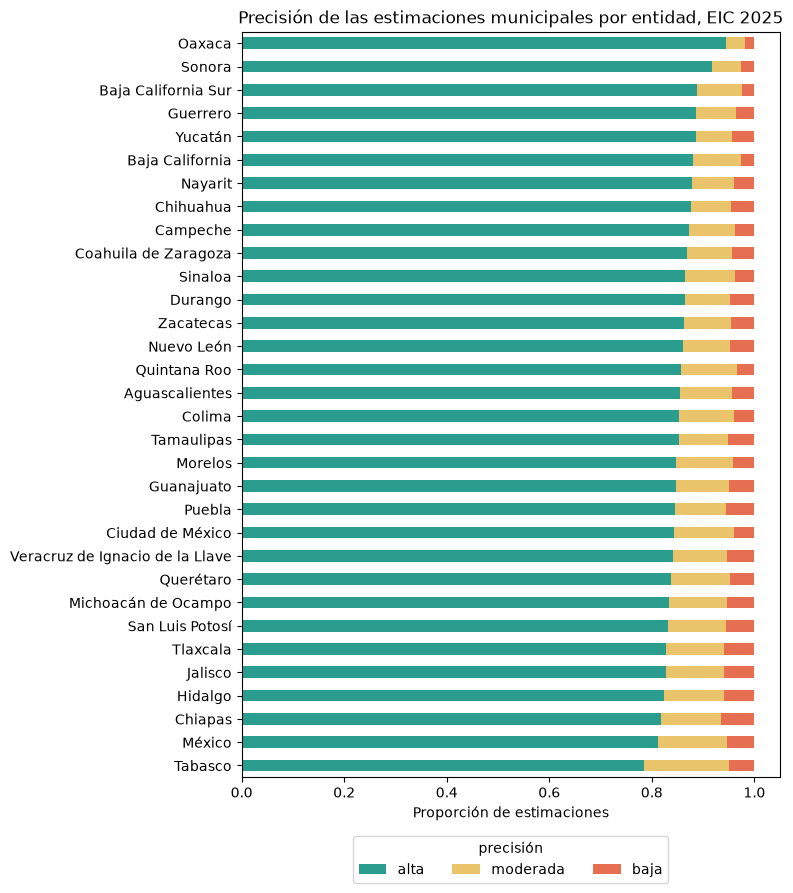

In [6]:
(mun.assign(precision=precision)
    .groupby("nom_ent")["precision"].value_counts(normalize=True).unstack()
    .sort_values("alta").plot.barh(stacked=True, figsize=(8, 9), color=["#2a9d8f", "#e9c46a", "#e76f51"], legend=False))
plt.title("Precisión de las estimaciones municipales por entidad, EIC 2025")
plt.xlabel("Proporción de estimaciones")
plt.ylabel("")
plt.legend(title="precisión", loc="upper center", bbox_to_anchor=(0.5, -0.07), ncols=3)
plt.tight_layout()

## 3. Distribución municipal de un indicador dentro de cada entidad

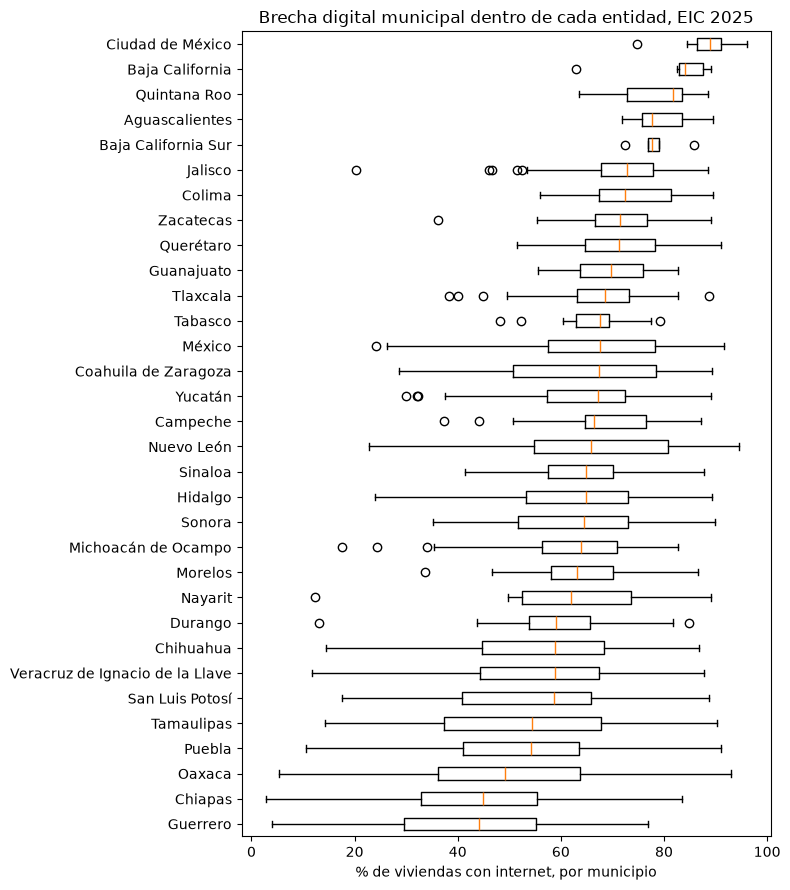

In [7]:
internet = mun[mun.indicador == "PCN_VPH_INTER"]
orden = internet.groupby("nom_ent")["valor"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 9))
ax.boxplot([internet.loc[internet.nom_ent == e, "valor"] for e in orden], tick_labels=orden, orientation="horizontal")
ax.set_xlabel("% de viviendas con internet, por municipio")
ax.set_title("Brecha digital municipal dentro de cada entidad, EIC 2025")
plt.tight_layout()

## 4. Sin descargar nada: DuckDB directo sobre la URL

DuckDB lee el Parquet remoto y solo baja lo que necesita.

In [8]:
import duckdb
duckdb.sql(f"""
    SELECT g.nom_ent, count(*) AS municipios, round(avg(e.valor), 1) AS promedio_sin_afiliacion
    FROM '{base}/estimacion.parquet' e
    JOIN '{base}/geografia.parquet' g USING (dataset_id, cvegeo)
    WHERE e.indicador = 'PCN_PSINDER' AND g.nivel = 'municipio'
    GROUP BY 1 ORDER BY 3 DESC LIMIT 10
""").df()

,nom_ent,municipios,promedio_sin_afiliacion
0,Michoacán de Ocampo,113,46.9
1,Oaxaca,570,42.1
2,Puebla,217,41.6
3,México,125,38.8
4,Chiapas,124,38.5
5,Hidalgo,84,38.1
6,Veracruz de Ignacio de la Llave,212,37.9
7,Zacatecas,58,36.4
8,Morelos,36,35.8
9,Guerrero,85,35.4


---
*Fuente: INEGI, Encuesta Intercensal 2015 y 2025. Datos servidos por [EIC API + MCP](https://github.com/zamax14/EIC-API-MCP).*